In [1]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle   

In [3]:
informatie = fits.getheader('m44_1-0004_g.fit') #naam document 
print(informatie)

SIMPLE  =                    T                                                  BITPIX  =                   16 /8 unsigned int, 16 & 32 int, -32 & -64 real     NAXIS   =                    2 /number of axes                                  NAXIS1  =                 4096 /fastest changing axis                           NAXIS2  =                 4096 /next to fastest changing axis                   BSCALE  =   1.0000000000000000 /physical = BZERO + BSCALE*array_value           BZERO   =   32768.000000000000 /physical = BZERO + BSCALE*array_value           DATE-OBS= '2026-03-04T21:25:05.30' /YYYY-MM-DDThh:mm:ss observation, UT         EXPTIME =   60.000000000000000 /Exposure time in seconds                        EXPOSURE=   60.000000000000000 /Exposure time in seconds                        SET-TEMP=  -10.000000000000000 /CCD temperature setpoint in C                   CCD-TEMP=  -10.062500000000000 /CCD temperature at start of exposure in C       XPIXSZ  =   9.0000000000000000 /Pixel Wi

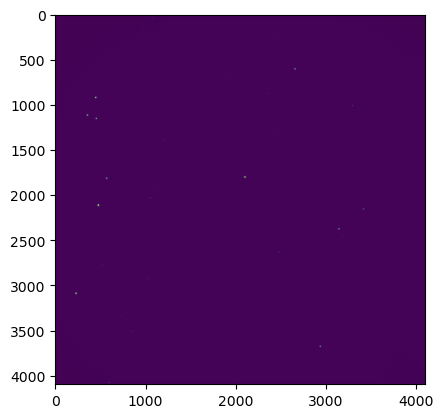

In [4]:
data_file = fits.getdata('m44_1-0004_g.fit') #naam document 
plt.imshow(data_file)

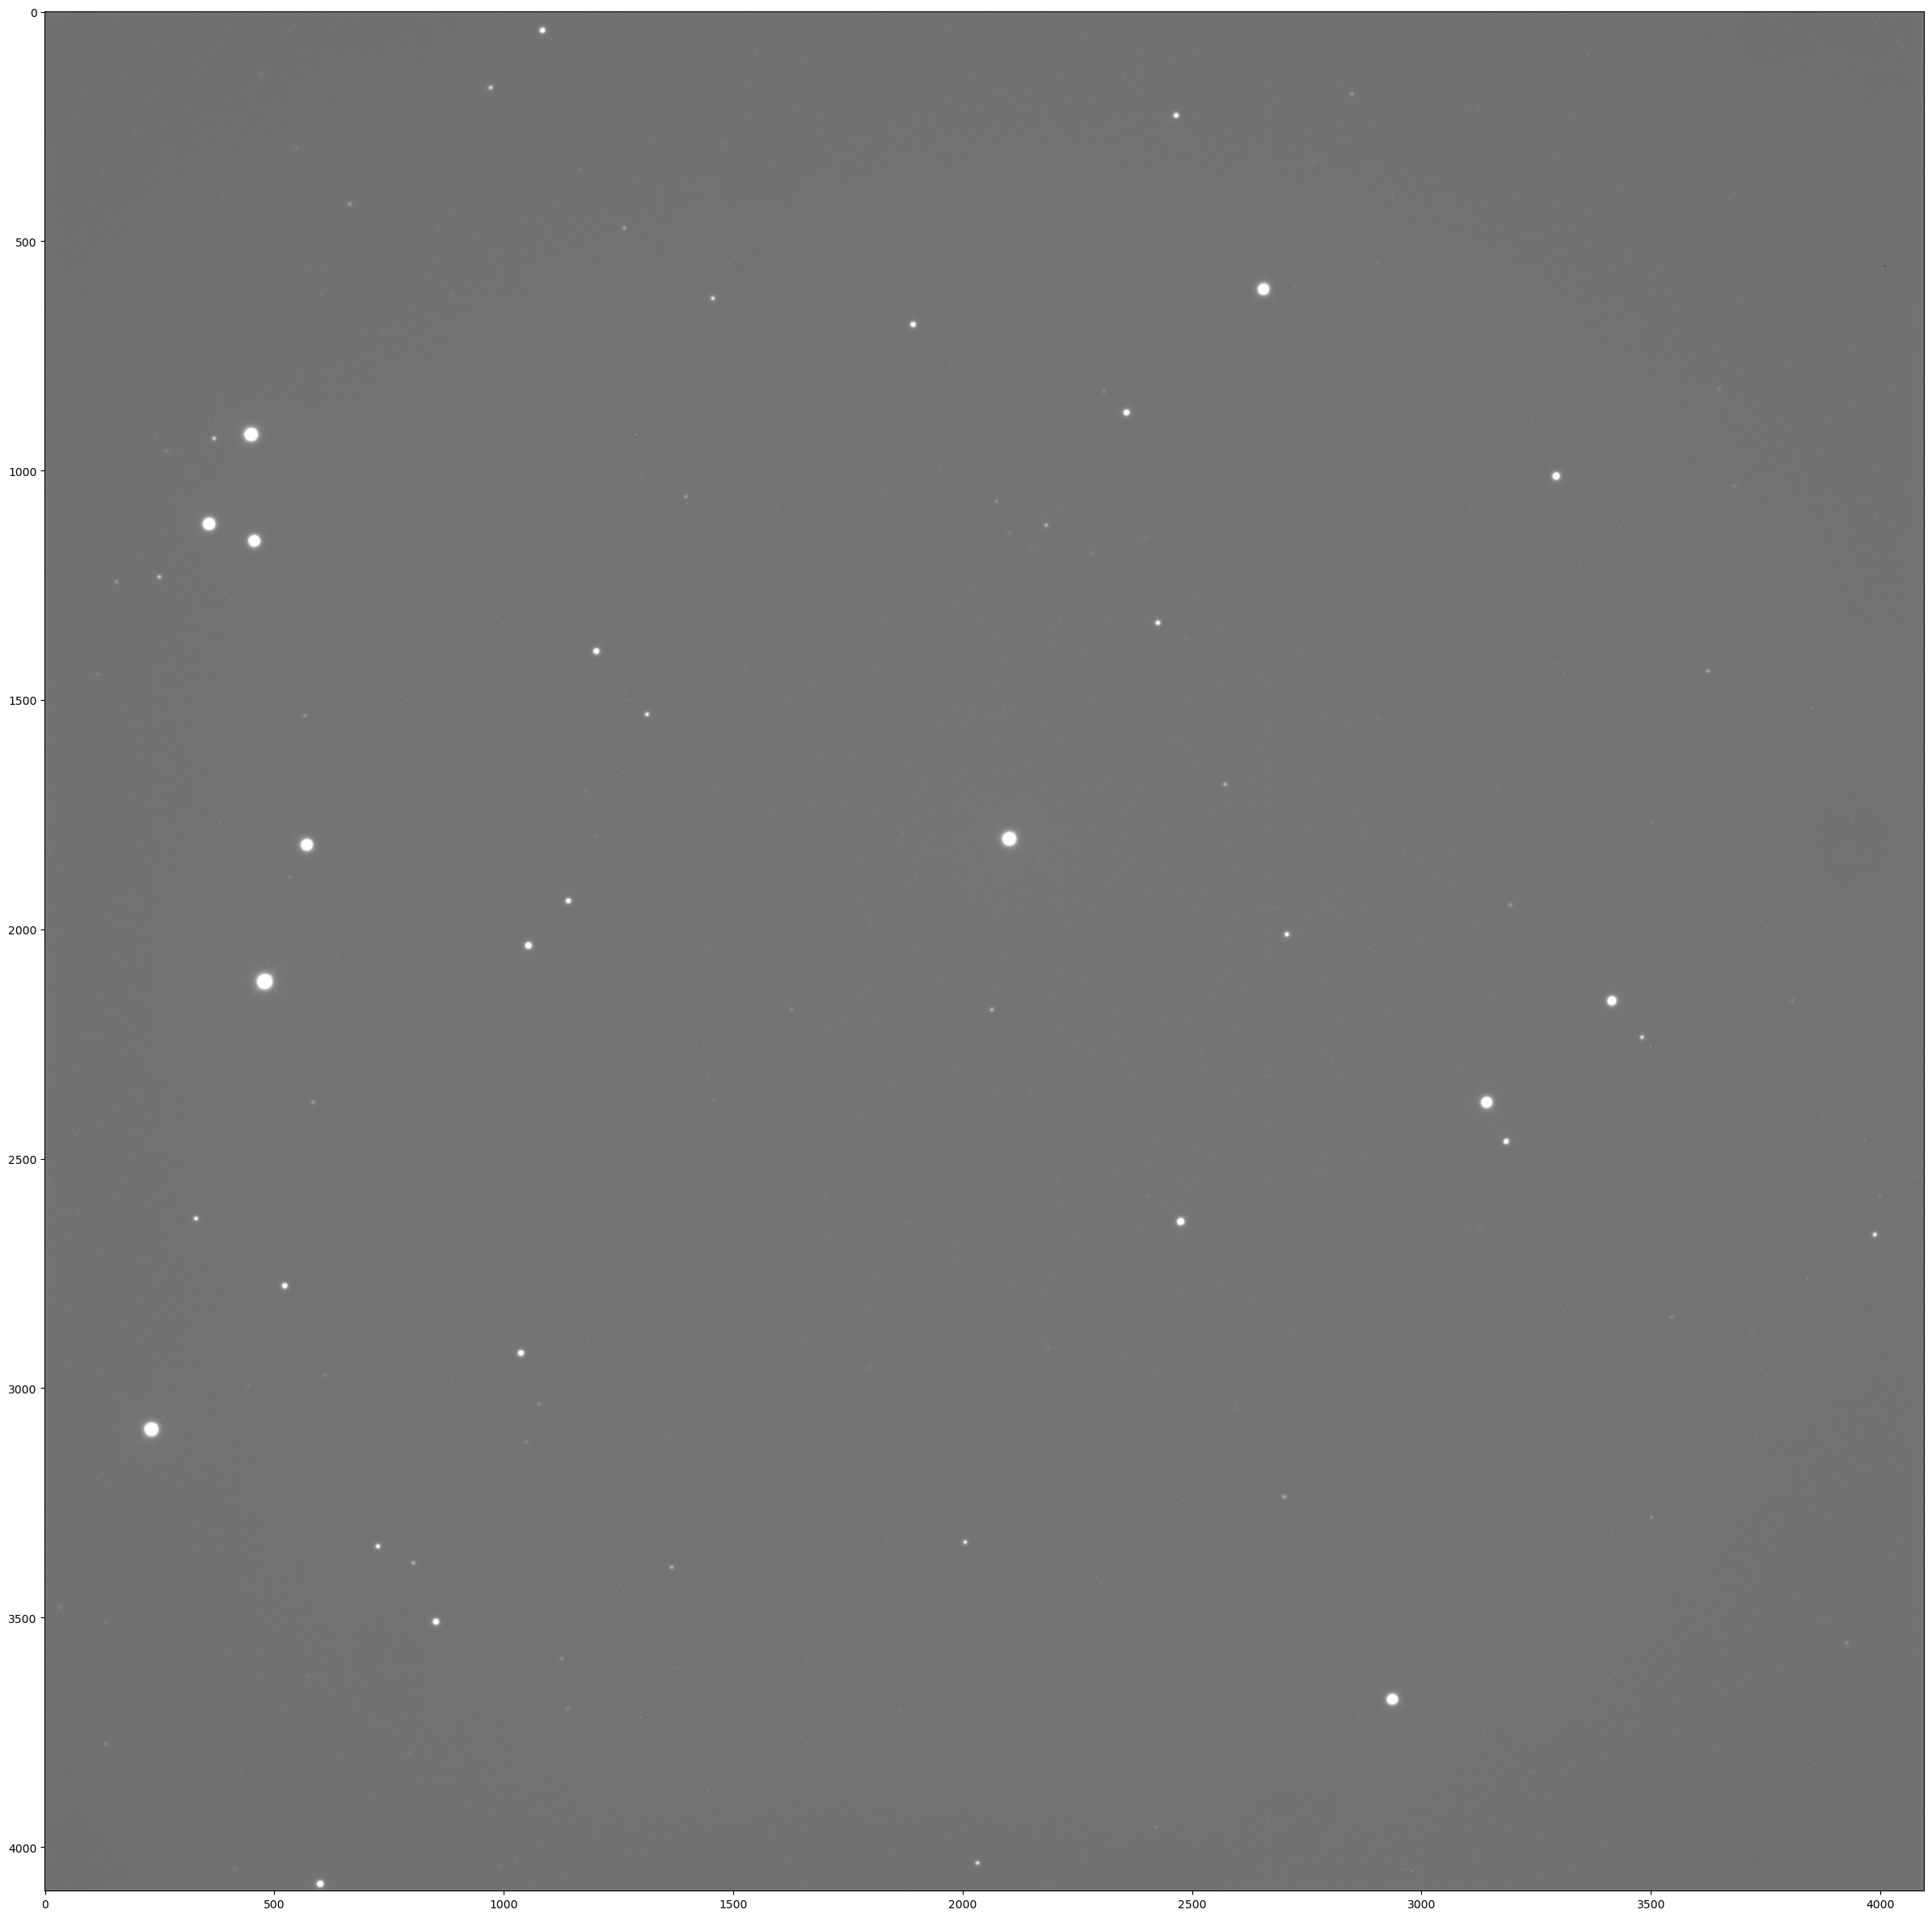

In [5]:
plt.figure(figsize = (30,45))
plt.imshow(data_file, vmin = 300, vmax= 5000, cmap= 'gray')
plt.show()

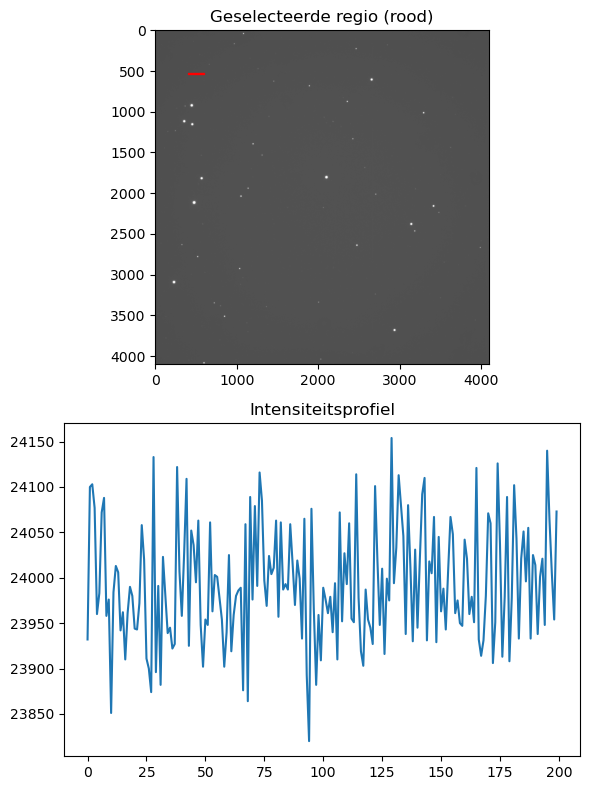

In [6]:
y_min = 520
y_max = 530

x_min = 400
x_max = 600

regio = data_file[y_min:y_max,x_min:x_max]
intensiteit = np.sum(regio, axis =0)

fig, axes = plt.subplots(2, 1, figsize=(6, 8))  # Twee subplots onder elkaar

# Eerste subplot: Beeld met rechthoek
axes[0].imshow(data_file, vmin=1000, vmax=5500, cmap='gray')
axes[0].add_patch(Rectangle((x_min, y_min), x_max - x_min, y_max - y_min,
                            edgecolor='red', facecolor='none', lw=1))
axes[0].set_title("Geselecteerde regio (rood)")

# Tweede subplot: Intensiteitsprofiel
axes[1].plot(intensiteit)
axes[1].set_title("Intensiteitsprofiel")

plt.tight_layout()  # Zorgt voor nette schikking van de subplots
plt.show()

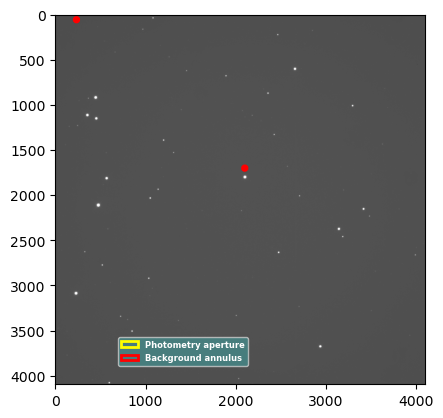

In [11]:
from photutils.aperture import CircularAnnulus, CircularAperture, aperture_photometry, ApertureStats

data_fotometrie = data_file


# 2 posities definieren:

positions = [(2100, 1700),(235, 55)]
aperture = CircularAperture(positions, r=7)
annulus_aperture = CircularAnnulus(positions, r_in=15, r_out=25)


# plaatje maken

plt.imshow(data_fotometrie, vmin = 1000, vmax= 5500, cmap= 'gray')

ap_patches = aperture.plot(color='yellow', lw=2,
                           label='Photometry aperture')
ann_patches = annulus_aperture.plot(color='red', lw=2,
                                    label='Background annulus')
handles = (ap_patches[0], ann_patches[0])
plt.legend(loc=(0.17, 0.05), facecolor='#458989', labelcolor='white',
           handles=handles, prop={'weight': 'bold', 'size': 6})
plt.show()

In [10]:
phot_table = aperture_photometry(data_fotometrie, aperture)

aperstats = ApertureStats(data_fotometrie, annulus_aperture)
bkg_mean = aperstats.mean
aperture_area = aperture.area_overlap(data_fotometrie)
total_bkg = bkg_mean * aperture_area

# %% Fotometrie


calibration_constant  = 26.57
phot_bkgsub = phot_table['aperture_sum'] - total_bkg
phot_table['total_bkg'] = total_bkg
phot_table['aperture_sum_bkgsub'] = phot_bkgsub
phot_table['instrumental magnitude'] = -2.5*np.log10(phot_bkgsub)
phot_table['calibrated magnitude'] = -2.5*np.log10(phot_bkgsub) + calibration_constant
for col in phot_table.colnames:
    phot_table[col].info.format = '%.8g'  # for consistent table output
print(phot_table)

 id x_center y_center ... instrumental magnitude calibrated magnitude
--- -------- -------- ... ---------------------- --------------------
  1       98       39 ...              -6.587388            19.982612
  2      235       55 ...                    nan                  nan


/var/folders/dv/s7w9wqz13rlf1qdn13573zn40000gp/T/ipykernel_16113/3016985397.py:15: RuntimeWarning: invalid value encountered in log10
  phot_table['instrumental magnitude'] = -2.5*np.log10(phot_bkgsub)
/var/folders/dv/s7w9wqz13rlf1qdn13573zn40000gp/T/ipykernel_16113/3016985397.py:16: RuntimeWarning: invalid value encountered in log10
  phot_table['calibrated magnitude'] = -2.5*np.log10(phot_bkgsub) + calibration_constant
